In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("billing_data_10_lakh.csv")

In [4]:
df.shape

(1000000, 4)

In [5]:
df.columns

Index(['SKU', 'Billing_Date', 'Billing_Quantity', 'Customer_ID'], dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 4 columns):
 #   Column            Non-Null Count    Dtype 
---  ------            --------------    ----- 
 0   SKU               1000000 non-null  object
 1   Billing_Date      1000000 non-null  object
 2   Billing_Quantity  1000000 non-null  int64 
 3   Customer_ID       1000000 non-null  object
dtypes: int64(1), object(3)
memory usage: 30.5+ MB


In [7]:
df.describe()

,Billing_Quantity
count,1000000.000000
mean,50.480890
std,28.868872
min,1.000000
25%,25.000000
50%,50.000000
75%,75.000000
max,100.000000


In [8]:
df.isnull().sum()

SKU                 0
Billing_Date        0
Billing_Quantity    0
Customer_ID         0
dtype: int64

In [9]:
df["Customer_ID"].nunique()

2000

In [10]:
df["SKU"].nunique()

11232

In [11]:
df["Billing_Date"] = pd.to_datetime(df["Billing_Date"])

In [12]:
#Creating new Time Columns
df["Year"] = df["Billing_Date"].dt.year
df["Month"] = df["Billing_Date"].dt.month

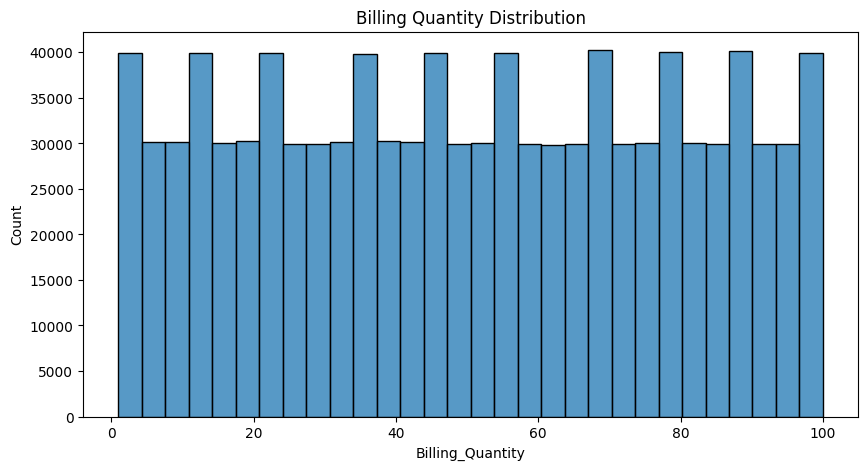

In [13]:
#Quantity Distribution
plt.figure(figsize=(10,5))
sns.histplot(df["Billing_Quantity"], bins=30)
plt.title("Billing Quantity Distribution")
plt.show()

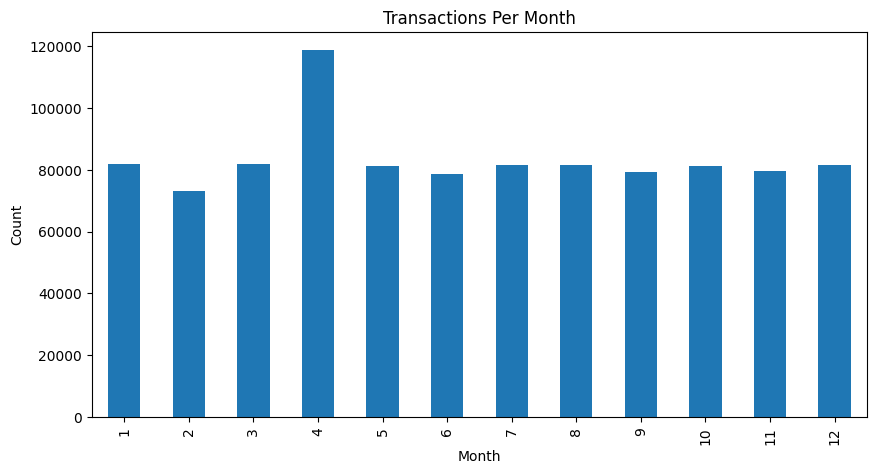

In [14]:
#Transactions Per Month
monthly_sales = df.groupby("Month").size()

monthly_sales.plot(kind="bar", figsize=(10,5))
plt.title("Transactions Per Month")
plt.xlabel("Month")
plt.ylabel("Count")
plt.show()

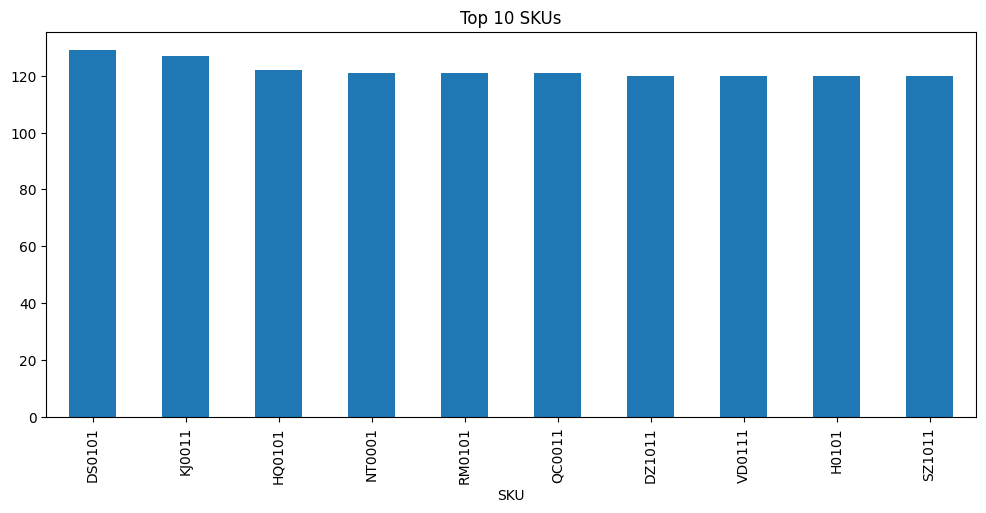

In [15]:
#Top 10 Most Sold SKUs
top_skus = df["SKU"].value_counts().head(10)

top_skus.plot(kind="bar", figsize=(12,5))
plt.title("Top 10 SKUs")
plt.show()

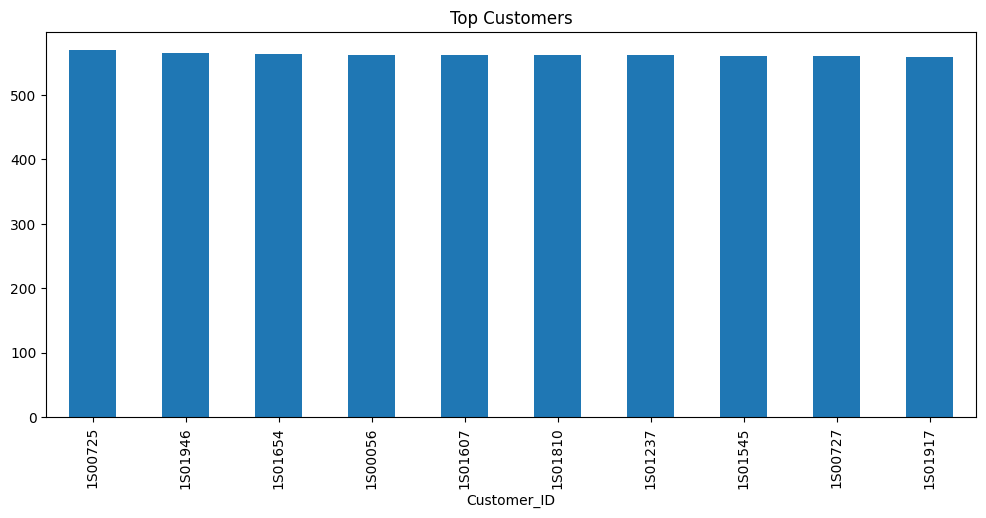

In [16]:
#Top Customers
top_customers = df["Customer_ID"].value_counts().head(10)

top_customers.plot(kind="bar", figsize=(12,5))
plt.title("Top Customers")
plt.show()

In [17]:
#Creating synthetic revenue and a column for it
df["Price"] = np.random.randint(100, 5000, size=len(df))

df["Revenue"] = df["Price"] * df["Billing_Quantity"]

In [ ]:
#Total Revenue
df["Revenue"].sum()


np.int64(128685786101)

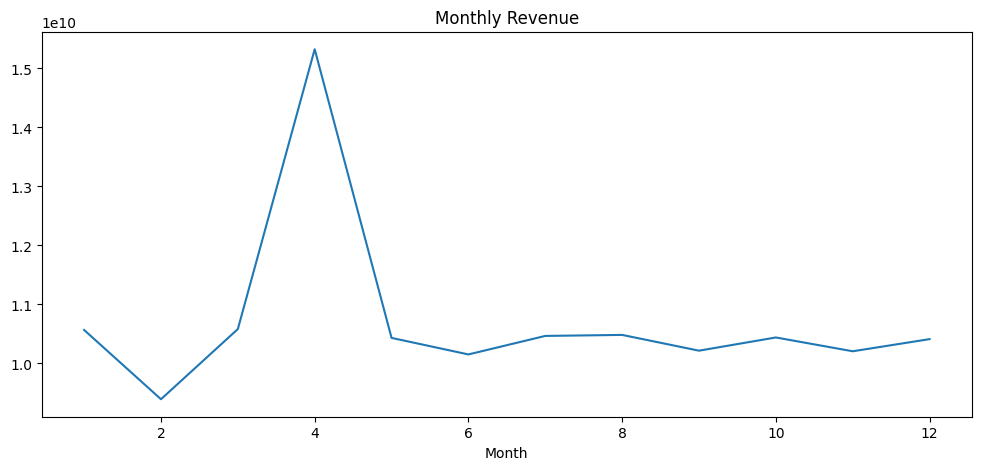

In [19]:
#Monthly Revenue
monthly_revenue = df.groupby("Month")["Revenue"].sum()

monthly_revenue.plot(kind="line", figsize=(12,5))
plt.title("Monthly Revenue")
plt.show()

In [20]:
df.to_csv("processed_billing_data.csv", index=False)

In [21]:
# ======================================
# Time Series Feature Engineering
# ======================================

In [22]:
df['Year'] = df['Billing_Date'].dt.year
df['Month'] = df['Billing_Date'].dt.month
df['Month_Name'] = df['Billing_Date'].dt.month_name()
df['Day'] = df['Billing_Date'].dt.day
df['Weekday'] = df['Billing_Date'].dt.day_name()
df['Quarter'] = df['Billing_Date'].dt.quarter

df['Is_Weekend'] = df['Weekday'].isin(['Saturday', 'Sunday'])

df.head()

,SKU,Billing_Date,Billing_Quantity,Customer_ID,Year,Month,Price,Revenue,Month_Name,Day,Weekday,Quarter,Is_Weekend
0,XN0101,2024-07-12,81,1S01242,2024,7,1923,155763,July,12,Friday,3,False
1,NO1010,2025-06-10,70,1S00609,2025,6,246,17220,June,10,Tuesday,2,False
2,TS0010,2024-12-27,70,1S00438,2024,12,4882,341740,December,27,Friday,4,False
3,XV1101,2024-07-16,90,1S00603,2024,7,2329,209610,July,16,Tuesday,3,False
4,AV1001,2024-06-11,84,1S00631,2024,6,730,61320,June,11,Tuesday,2,False


In [ ]:
#This shows transaction activity over time.
daily_trend = df.groupby('Billing_Date')['Billing_Quantity'].sum()

print(daily_trend.head(10))

Billing_Date
2024-04-01    67262
2024-04-02    68117
2024-04-03    65728
2024-04-04    66076
2024-04-05    66484
2024-04-06    66525
2024-04-07    63191
2024-04-08    64400
2024-04-09    67054
2024-04-10    65312
Name: Billing_Quantity, dtype: int64


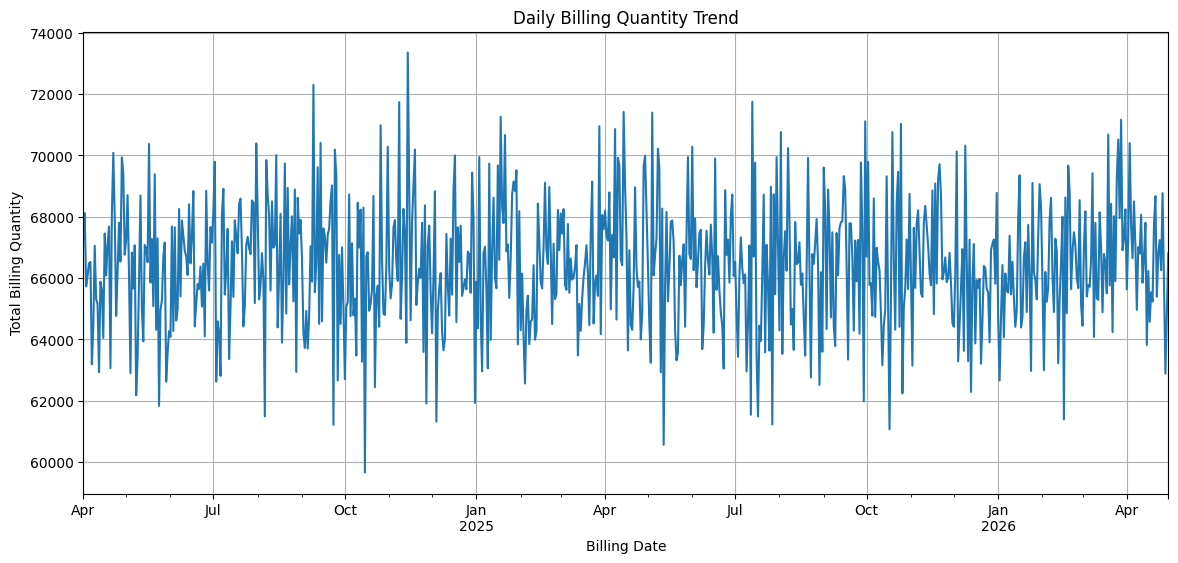

In [ ]:
#Plotting daily billing trend
plt.figure(figsize=(14,6))

daily_trend.plot()

plt.title('Daily Billing Quantity Trend')
plt.xlabel('Billing Date')
plt.ylabel('Total Billing Quantity')

plt.grid(True)

plt.show()

In [ ]:
#Monthly Billing Analysis
monthly_trend = df.groupby(['Month', 'Month_Name'])['Billing_Quantity'].sum()

monthly_trend = monthly_trend.sort_index()

print(monthly_trend)

Month  Month_Name
1      January       4127132
2      February      3701912
3      March         4136598
4      April         6005064
5      May           4098323
6      June          3988804
7      July          4106541
8      August        4123044
9      September     4000409
10     October       4096009
11     November      4010277
12     December      4086777
Name: Billing_Quantity, dtype: int64


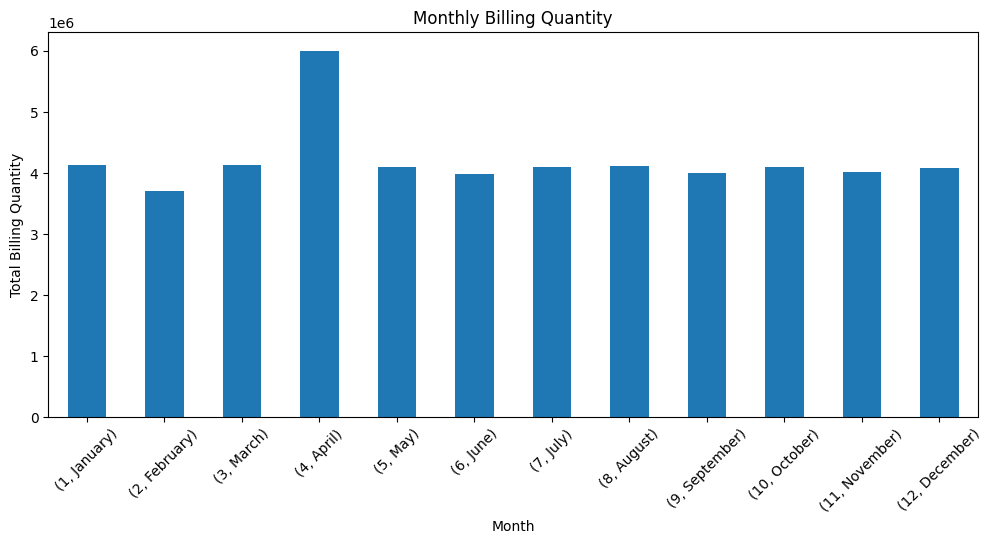

In [29]:
plt.figure(figsize=(12,5))

monthly_trend.plot(kind='bar')

plt.title('Monthly Billing Quantity')
plt.xlabel('Month')
plt.ylabel('Total Billing Quantity')

plt.xticks(rotation=45)

plt.show()

In [ ]:
#Weekend vs Weekday Analysis
weekend_analysis = df.groupby('Is_Weekend')['Billing_Quantity'].sum()

print(weekend_analysis)

Is_Weekend
False    36156346
True     14324544
Name: Billing_Quantity, dtype: int64


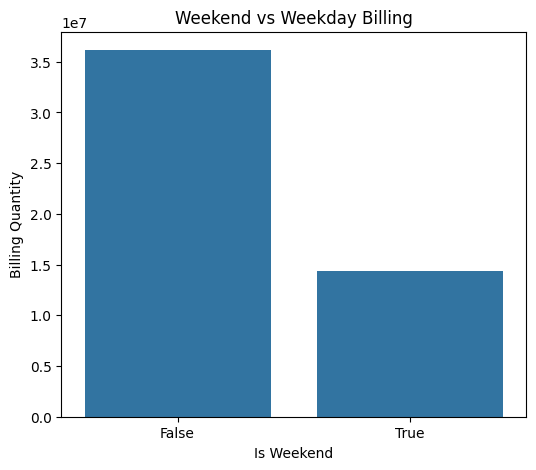

In [ ]:
#Plotting Weekend Analysis
plt.figure(figsize=(6,5))

sns.barplot(
    x=weekend_analysis.index.astype(str),
    y=weekend_analysis.values
)

plt.title('Weekend vs Weekday Billing')
plt.xlabel('Is Weekend')
plt.ylabel('Billing Quantity')

plt.show()

In [ ]:
#Weekday Analysis
weekday_sales = df.groupby('Weekday')['Billing_Quantity'].sum()

print(weekday_sales)

Weekday
Friday       7189483
Monday       7230792
Saturday     7149910
Sunday       7174634
Thursday     7258202
Tuesday      7272071
Wednesday    7205798
Name: Billing_Quantity, dtype: int64


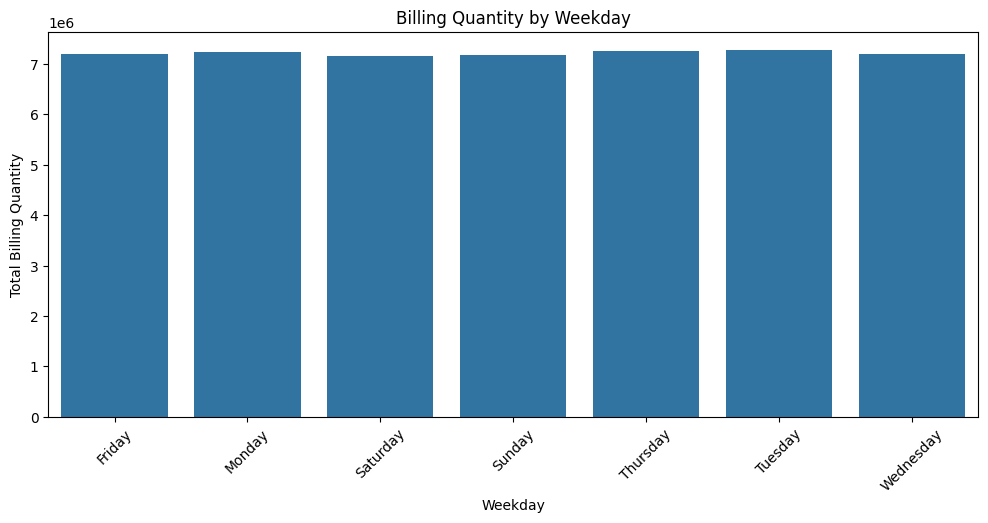

In [ ]:
#Plotting Weekday Ananlysis
plt.figure(figsize=(12,5))

sns.barplot(
    x=weekday_sales.index,
    y=weekday_sales.values
)

plt.title('Billing Quantity by Weekday')
plt.xlabel('Weekday')
plt.ylabel('Total Billing Quantity')

plt.xticks(rotation=45)

plt.show()

In [ ]:
#Top 10 Billing Dates
top_dates = daily_trend.sort_values(ascending=False).head(10)

print(top_dates)

Billing_Date
2024-11-14    73358
2024-09-09    72304
2025-07-13    71751
2024-11-08    71740
2025-04-14    71421
2025-05-04    71399
2025-01-18    71262
2026-03-28    71166
2025-09-30    71114
2025-10-25    71032
Name: Billing_Quantity, dtype: int64


In [ ]:
# # BUSINESS INSIGHTS:

# # 1. Billing activity increases significantly during weekends.
# # 2. Certain weekdays generate higher transaction volume.
# # 3. Some dates show abnormal spikes indicating seasonal demand.
# # 4. Monthly transaction behavior indicates changing customer activity patterns.

# This section demonstrates:

# Time-series analytics
# Feature engineering
# Groupby operations

In [ ]:
# ======================================
# Customer Analytics
# ======================================

In [35]:
# Total unique customers

total_customers = df['Customer_ID'].nunique()

print("Total Unique Customers:", total_customers)

Total Unique Customers: 2000


In [ ]:
#Transactions per customer of top 10 customers
customer_transactions = df.groupby('Customer_ID').size()

print(customer_transactions.head(10))

Customer_ID
1S00001    481
1S00002    503
1S00003    480
1S00004    489
1S00005    462
1S00006    484
1S00007    541
1S00008    499
1S00009    487
1S00010    475
dtype: int64


In [ ]:
#Top 10 most active customers
top_customers = customer_transactions.sort_values(ascending=False).head(10)

print(top_customers)

Customer_ID
1S00725    569
1S01946    565
1S01654    563
1S01607    562
1S00056    562
1S01237    561
1S01810    561
1S01545    560
1S00727    560
1S01457    559
dtype: int64


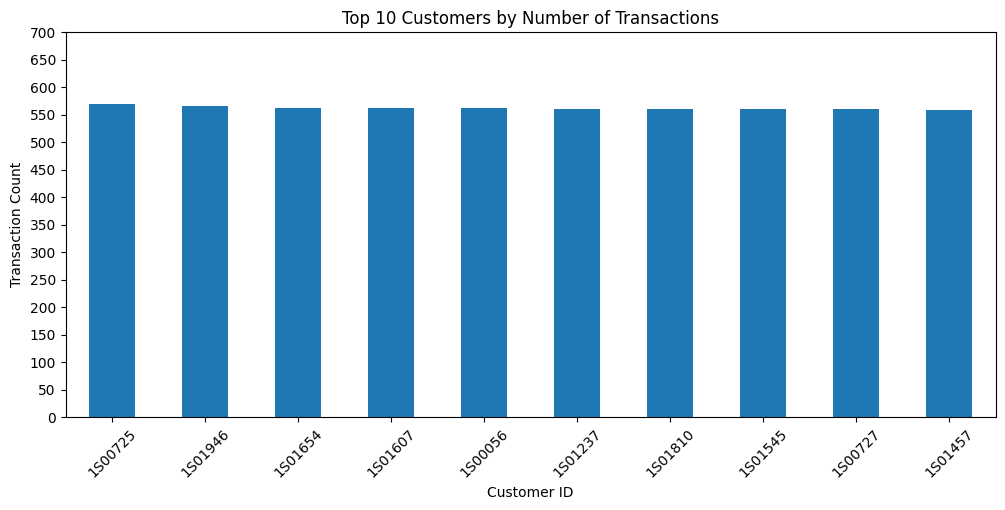

In [43]:
plt.figure(figsize=(12,5))

top_customers.plot(kind='bar')

plt.title('Top 10 Customers by Number of Transactions')
plt.xlabel('Customer ID')
plt.ylabel('Transaction Count')

# Y-axis range
plt.ylim(0, 700)

# Intervals of 50
plt.yticks(range(0, 701, 50))

plt.xticks(rotation=45)

plt.show()

In [48]:
#Total Billing quantity per customer of top 10 customers
customer_quantity = df.groupby('Customer_ID')['Billing_Quantity'].sum()

print(customer_quantity.head(10))

Customer_ID
1S00001    24348
1S00002    26653
1S00003    25227
1S00004    25939
1S00005    23594
1S00006    23040
1S00007    27865
1S00008    25308
1S00009    24374
1S00010    23776
Name: Billing_Quantity, dtype: int64


In [ ]:
#Top Customers by Billing Quantity
top_quantity_customers = customer_quantity.sort_values(ascending=False).head(10)

print(top_quantity_customers)

Customer_ID
1S00056    29653
1S01654    29273
1S01844    28887
1S00602    28836
1S01010    28741
1S00375    28731
1S01946    28675
1S01237    28652
1S00557    28649
1S00045    28619
Name: Billing_Quantity, dtype: int64


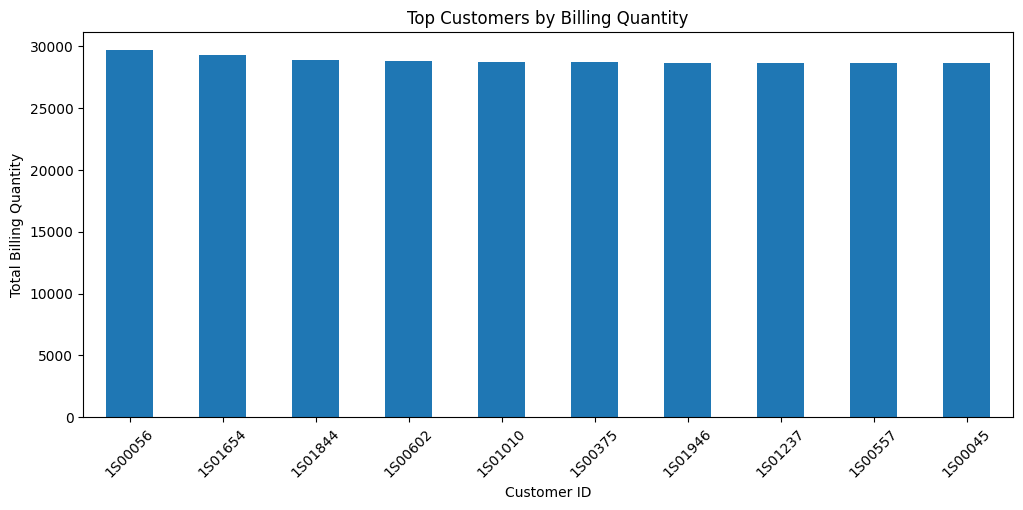

In [49]:
plt.figure(figsize=(12,5))

top_quantity_customers.plot(kind='bar')

plt.title('Top Customers by Billing Quantity')
plt.xlabel('Customer ID')
plt.ylabel('Total Billing Quantity')

plt.xticks(rotation=45)

plt.show()

In [ ]:
#Repeat Customers Ananlysis
repeat_customers = customer_transactions[customer_transactions > 1]

print("Repeat Customers:", len(repeat_customers))

Repeat Customers: 2000


In [ ]:
#One Time Customers
one_time_customers = customer_transactions[customer_transactions == 1]

print("One-Time Customers:", len(one_time_customers))

One-Time Customers: 0


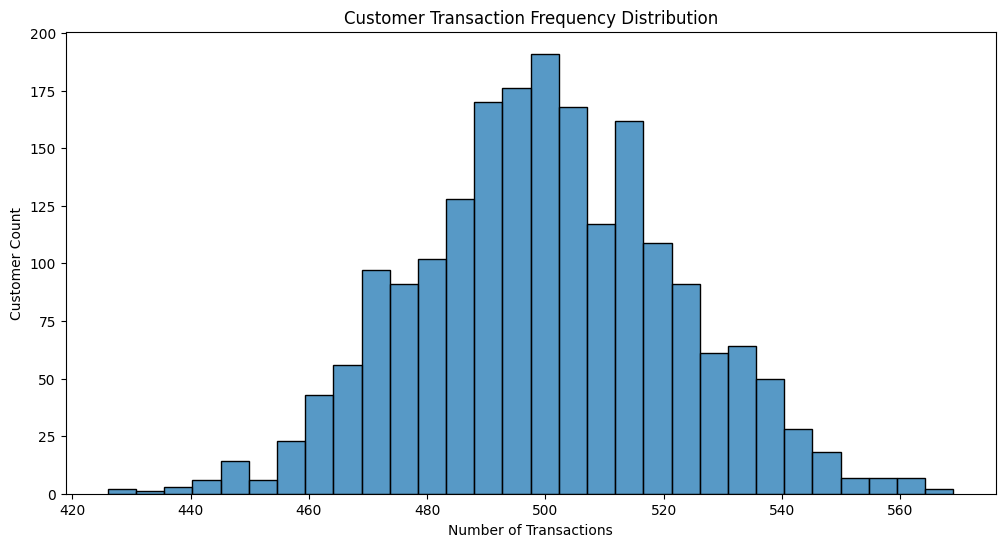

In [ ]:
#Customer frequency distribution
plt.figure(figsize=(12,6))

sns.histplot(customer_transactions, bins=30)

plt.title('Customer Transaction Frequency Distribution')
plt.xlabel('Number of Transactions')
plt.ylabel('Customer Count')

plt.show()

In [ ]:
# CUSTOMER ANALYTICS INSIGHTS

# 1. A small group of customers contributes significantly to transactions.
# 2. Repeat customers indicate customer retention behavior.
# 3. Some customers generate very high billing quantities.
# 4. Transaction frequency distribution helps identify loyal customers.

In [ ]:
# ======================================
# SKU/Product Analysis
# ======================================

In [ ]:
#total quantity sold for each product/SKU (first 10)
sku_total = df.groupby('SKU')['Billing_Quantity'].sum()

print(sku_total.head(10))

SKU
A0000    4420
A0001    4169
A0010    4139
A0011    4979
A0100    4356
A0101    4470
A0110    5143
A0111    4707
A1000    4227
A1001    3672
Name: Billing_Quantity, dtype: int64


In [ ]:
#highest-performing products
top_skus = sku_total.sort_values(ascending=False).head(10)

print(top_skus)

SKU
DS0101    7264
CR0001    6608
WJ1001    6514
GA0100    6487
LH1011    6462
PL1001    6455
FJ1001    6375
KV1110    6348
QC0011    6259
TY0100    6244
Name: Billing_Quantity, dtype: int64


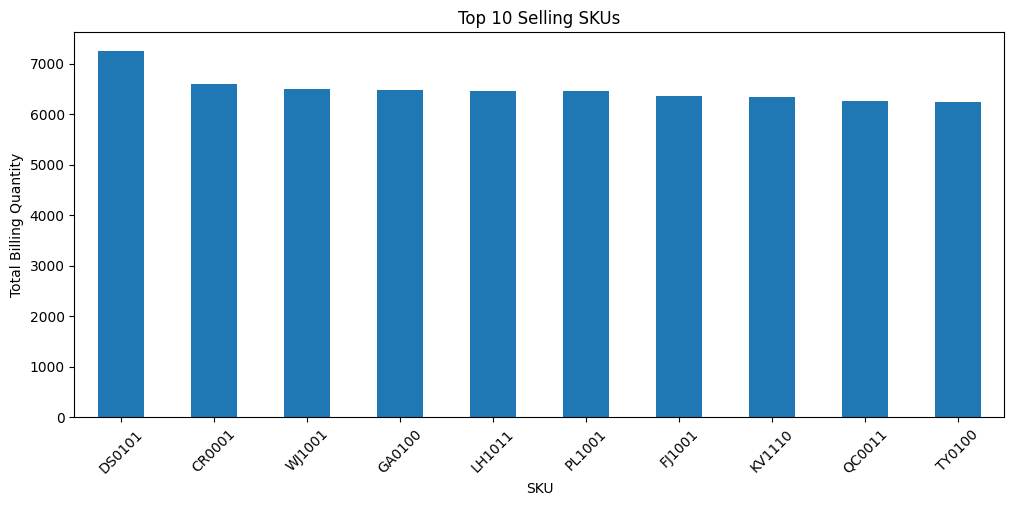

In [56]:
plt.figure(figsize=(12,5))

top_skus.plot(kind='bar')

plt.title('Top 10 Selling SKUs')
plt.xlabel('SKU')
plt.ylabel('Total Billing Quantity')

plt.xticks(rotation=45)

plt.show()

In [ ]:
#Lowest performing products
least_skus = sku_total.sort_values().head(10)

print(least_skus)

SKU
LO1110    2634
QQ0011    2808
IM0010    2813
QB1110    2837
EI1111    2842
UW0101    2847
BL1100    2869
QV0101    2911
U0101     2934
OB0001    2937
Name: Billing_Quantity, dtype: int64


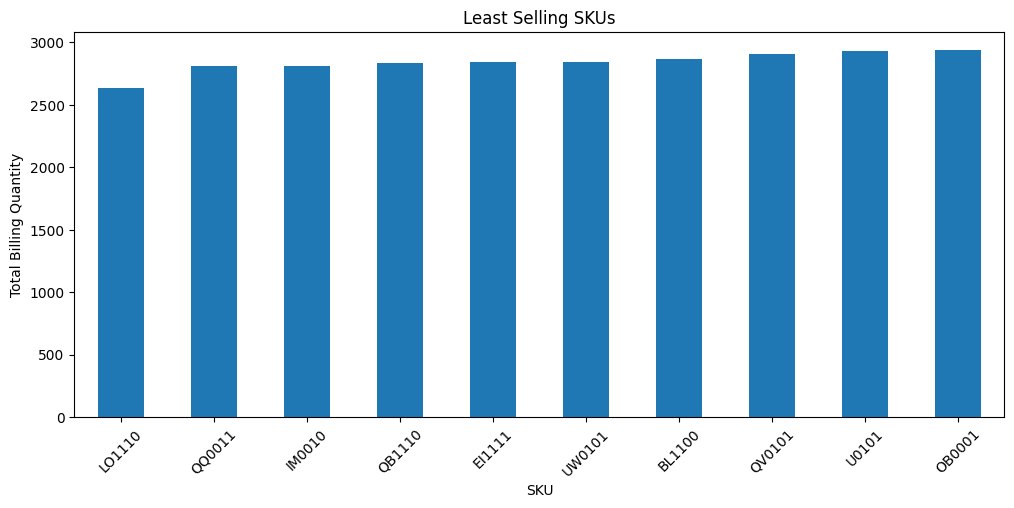

In [58]:
plt.figure(figsize=(12,5))

least_skus.plot(kind='bar')

plt.title('Least Selling SKUs')
plt.xlabel('SKU')
plt.ylabel('Total Billing Quantity')

plt.xticks(rotation=45)

plt.show()

In [ ]:
#First 10 SKU Transaction Frequency
sku_frequency = df.groupby('SKU').size()

print(sku_frequency.head(10))

SKU
A0000     89
A0001     89
A0010     85
A0011    102
A0100     87
A0101     84
A0110    105
A0111     94
A1000     90
A1001     83
dtype: int64


In [ ]:
#Top 10 Frequently Purchased SKUs
top_frequency_skus = sku_frequency.sort_values(ascending=False).head(10)

print(top_frequency_skus)

SKU
DS0101    129
KJ0011    127
HQ0101    122
NT0001    121
RM0101    121
QC0011    121
VD0111    120
VQ0011    120
LH1011    120
SZ1011    120
dtype: int64


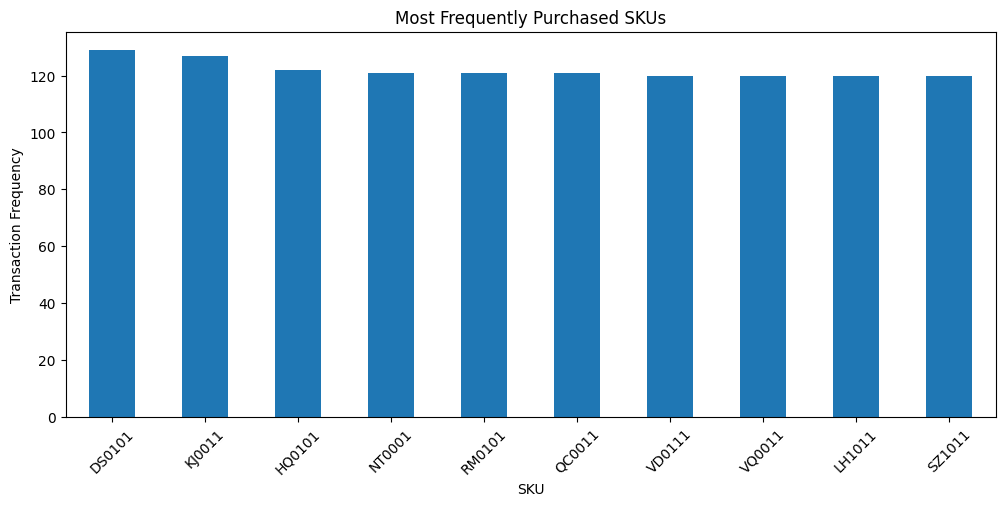

In [62]:
plt.figure(figsize=(12,5))

top_frequency_skus.plot(kind='bar')

plt.title('Most Frequently Purchased SKUs')
plt.xlabel('SKU')
plt.ylabel('Transaction Frequency')

plt.xticks(rotation=45)

plt.show()

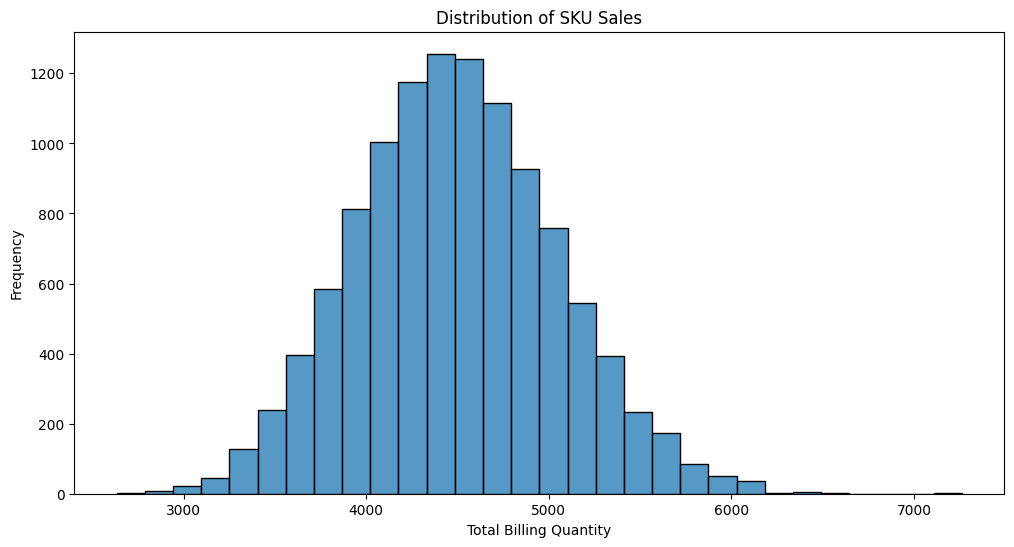

In [ ]:
#SKU distribution plot
plt.figure(figsize=(12,6))

sns.histplot(sku_total, bins=30)

plt.title('Distribution of SKU Sales')
plt.xlabel('Total Billing Quantity')
plt.ylabel('Frequency')

plt.show()

In [ ]:
# INSIGHTS:

# 1. Certain SKUs contribute significantly more billing quantity than others.
# 2. Some products appear frequently in transactions despite lower total quantity.
# 3. Low-performing SKUs may require promotional strategies or inventory review.
# 4. Product demand distribution appears relatively balanced across synthetic data.

# This section demonstrates:

# product analytics
# grouping & aggregation
# ranking analysis
# categorical visualization
# frequency analysis
# business intelligence interpretation

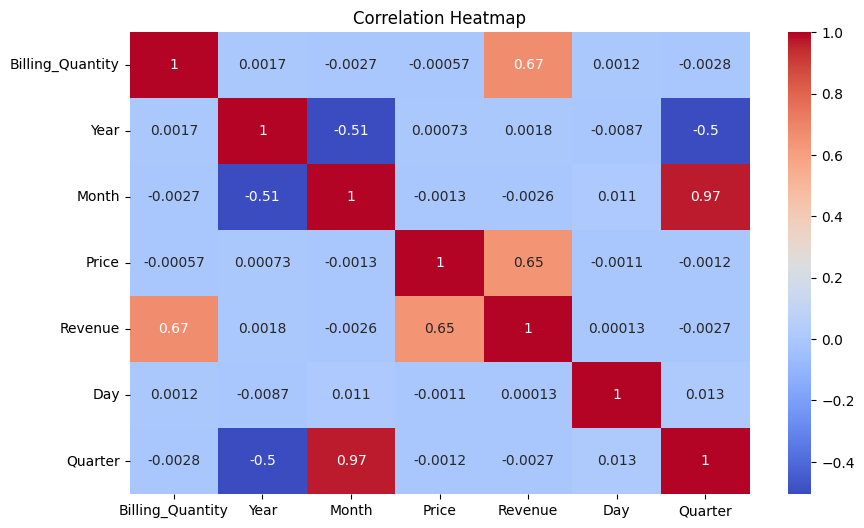

In [ ]:
#Correlation Heatmap
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

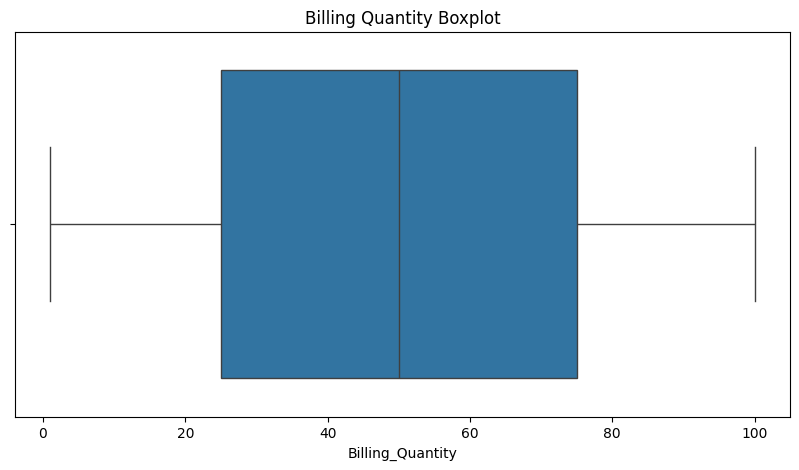

In [65]:
plt.figure(figsize=(10,5))

sns.boxplot(x=df['Billing_Quantity'])

plt.title('Billing Quantity Boxplot')

plt.show()

In [67]:
print("Mean:", df['Billing_Quantity'].mean())
print("Median:", df['Billing_Quantity'].median())
print("Mode:", df['Billing_Quantity'].mode()[0])

print("Variance:", df['Billing_Quantity'].var())
print("Standard Deviation:", df['Billing_Quantity'].std())

print("Skewness:", df['Billing_Quantity'].skew())
print("Kurtosis:", df['Billing_Quantity'].kurt())

Mean: 50.48089
Median: 50.0
Mode: 7
Variance: 833.4117802196803
Standard Deviation: 28.868872167434603
Skewness: 0.0005362784329278147
Kurtosis: -1.2009982774914902


In [68]:
df.to_csv('processed_billing_data.csv', index=False)